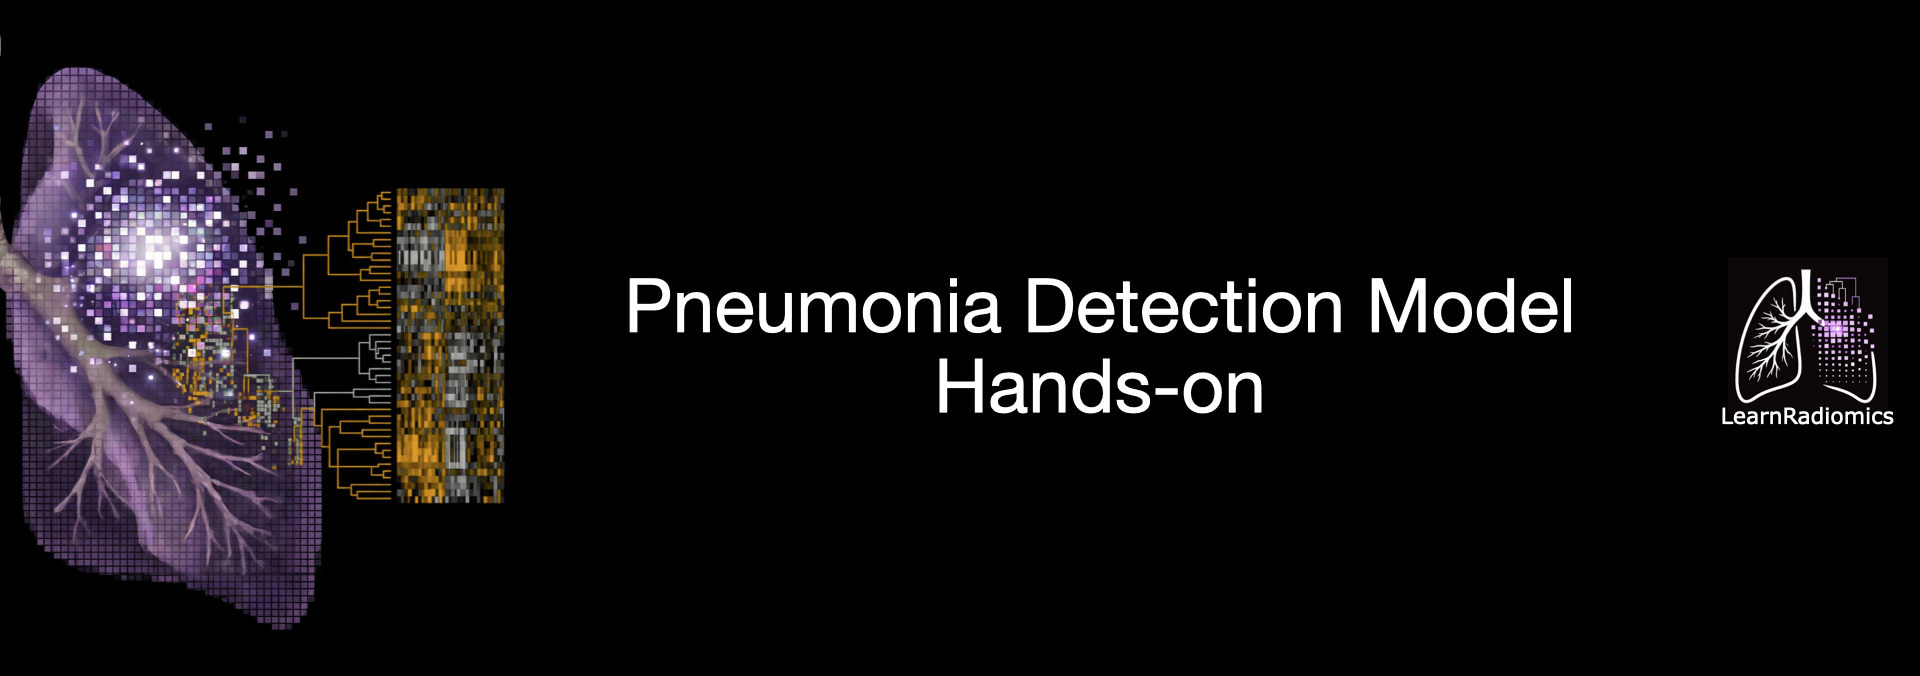

In [ ]:
!pip install -q ultralytics

In [ ]:
## Import libraries
import pandas as pd
import numpy as np
import cv2
import os
import random
from collections import Counter
import matplotlib.pyplot as plt
from ultralytics import YOLO

import requests
import json
import warnings
warnings.filterwarnings('ignore')

## Downloading the Kaggle token that allows access to the dataset
json_response= requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")
token = json.loads(json_response.text)
with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load data from kaggle
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download -d hshenriquez/learnradiomics-pneumonia-detection-hands-on

!unzip -q /content/learnradiomics-pneumonia-detection-hands-on.zip

In [ ]:
### Visualization
def plot_yolo_annotation(image_path, label_path):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
    else:
        lines = []

    for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.strip().split())

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(img, (x1, y1), (x2, y2), (176, 39, 245), 3)


    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

In [ ]:
## Directories
from pathlib import Path

dataset_path = Path('/content/pneumonia_detection')

images_train_dir = dataset_path / "images" / "train"
images_val_dir   = dataset_path / "images" / "val"
labels_train_dir = dataset_path / "labels" / "train"
labels_val_dir   = dataset_path / "labels" / "val"


In [ ]:
### Positive Cases

positive_label_files = [
    p for p in labels_train_dir.glob("*.txt")
    if os.path.getsize(p) > 0
]

sample_label = random.choice(positive_label_files)
sample_image = images_train_dir / f"{sample_label.stem}.png"

plot_yolo_annotation(sample_image, sample_label)

with open(sample_label, "r") as f:
            lines = f.readlines()
for line in lines:
        class_id, xc, yc, bw, bh = map(float, line.strip().split())
        print("Class:", class_id)
        print("x center:", xc)
        print("y center:", yc)
        print("box width:", bw)
        print("box height:", bh)

In [ ]:
### Model Training

model = YOLO("yolov8n.pt")

EPOCHS = 30
BATCH_SIZE = 64

results = model.train(
    data="/content/pneumonia_detection/yolo_pneumonia.yaml",
    epochs=EPOCHS,
    imgsz=512,
    batch=BATCH_SIZE,
    project="content/runs",
    name="pneumonia_yolov8n",
    pretrained=True
)

In [ ]:
## Metrics

metrics = model.val(
    data="/content/pneumonia_detection/yolo_pneumonia.yaml",
    imgsz=512,
    batch=64
)

In [ ]:
metrics.results_dict

In [ ]:
def yolo_to_xyxy(xc, yc, w, h, img_width, img_height):
    """
    Convert normalized YOLO format::
    x_center, y_center, width, height
    to coordinates:
    x1, y1, x2, y2
    """
    x1 = int((xc - w / 2) * img_width)
    y1 = int((yc - h / 2) * img_height)
    x2 = int((xc + w / 2) * img_width)
    y2 = int((yc + h / 2) * img_height)

    return x1, y1, x2, y2

def plot_pred_vs_gt(
    image_path,
    label_path,
    prediction,
    conf_threshold=0.25
):
    # Load Image
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_height, img_width = img.shape[:2]

    # Copy img to plot
    img_plot = img.copy()

    # -------------------------
    # 1. Draw Ground Truth
    # -------------------------
    if Path(label_path).exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            if line.strip() == "":
                continue

            class_id, xc, yc, bw, bh = map(float, line.strip().split())

            x1, y1, x2, y2 = yolo_to_xyxy(
                xc, yc, bw, bh,
                img_width,
                img_height
            )

            # Real Box: Green
            cv2.rectangle(
                img_plot,
                (x1, y1),
                (x2, y2),
                color=(0, 255, 0),
                thickness=3
            )

            cv2.putText(
                img_plot,
                "GT",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )

    # -------------------------
    # 2. Draw Predictions
    # -------------------------
    boxes = prediction[0].boxes

    if boxes is not None and len(boxes) > 0:
        xyxy = boxes.xyxy.cpu().numpy()
        confs = boxes.conf.cpu().numpy()
        classes = boxes.cls.cpu().numpy()

        for box, conf, cls in zip(xyxy, confs, classes):
            if conf < conf_threshold:
                continue

            x1, y1, x2, y2 = box.astype(int)

            # Predicted Box: Purple...LearnRadiomics Color ;)
            cv2.rectangle(
                img_plot,
                (x1, y1),
                (x2, y2),
                color=(176, 39, 245),
                thickness=3
            )

            label = f"Pred {conf:.2f}"

            cv2.putText(
                img_plot,
                label,
                (x1, min(y2 + 25, img_height - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (176, 39, 245),
                2
            )

    # -------------------------
    # 3. Show
    # -------------------------
    plt.figure(figsize=(8, 8))
    plt.imshow(img_plot)
    plt.axis("off")
    plt.title("Ground truth vs predicción")
    plt.show()

In [ ]:
### Load Trained Model
best_model_path = "/content/runs/detect/content/runs/pneumonia_yolov8n-2/weights/best.pt"

model = YOLO(best_model_path)

In [ ]:
positive_val_labels = [
    p for p in labels_val_dir.glob("*.txt")
    if p.stat().st_size > 0
]

sample_label = random.choice(positive_val_labels)
sample_img = images_val_dir / f"{sample_label.stem}.png"

pred = model.predict(
    source=str(sample_img),
    imgsz=512,
    conf=0.2,
    save=False
)

plot_pred_vs_gt(
    image_path=sample_img,
    label_path=sample_label,
    prediction=pred,
    conf_threshold=0.2
)